# Experiment No 4

**Aim:** To build Linear and Logistic Regression models on the Spambase dataset and evaluate their performance using appropriate metrics.

### Step 1: Import Libraries and Load Dataset

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# Fetch the Spambase dataset
spambase = fetch_ucirepo(id=94)
X = spambase.data.features
y = spambase.data.targets

# Combine into a single DataFrame
df = pd.concat([X, y], axis=1)
print('Dataset loaded successfully.')
print(f'Shape: {df.shape}')

Dataset loaded successfully.
Shape: (4601, 58)


### Step 2: Data Overview

In [12]:
print('--- First 5 rows ---')
display(df.head())

print('\n--- Class Distribution ---')
print(df['Class'].value_counts())
print(f"\nSpam %: {df['Class'].mean()*100:.2f}%")

--- First 5 rows ---


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1



--- Class Distribution ---
Class
0    2788
1    1813
Name: count, dtype: int64

Spam %: 39.40%


### Step 3: Preprocessing – Train/Test Split & Feature Scaling

In [13]:
# Features and target
X_data = df.drop(columns=['Class'])
y_data = df['Class']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 3680
Testing  samples : 921


### Step 4: Linear Regression

We apply Linear Regression to treat this as a regression problem (target = 0 or 1).
Predictions are then **thresholded at 0.5** to produce binary class labels for comparison.

In [14]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Continuous predictions
y_pred_lr_cont = lr.predict(X_test_scaled)

# Regression metrics
mse  = mean_squared_error(y_test, y_pred_lr_cont)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_lr_cont)

print('--- Linear Regression Metrics ---')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')

# Threshold predictions for classification comparison
y_pred_lr_class = (y_pred_lr_cont >= 0.5).astype(int)
acc_lr = accuracy_score(y_test, y_pred_lr_class)
print(f'\nAccuracy (threshold=0.5): {acc_lr*100:.2f}%')

--- Linear Regression Metrics ---
MSE  : 0.1069
RMSE : 0.3270
R²   : 0.5523

Accuracy (threshold=0.5): 88.27%


### Visualisation – Linear Regression: Actual vs Predicted

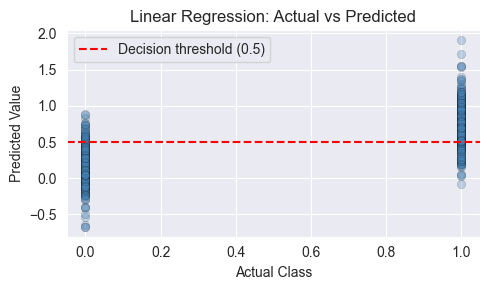

In [20]:
plt.figure(figsize=(5, 3))
plt.scatter(y_test, y_pred_lr_cont, alpha=0.3, color='steelblue', edgecolors='k', linewidths=0.3)
plt.axhline(0.5, color='red', linestyle='--', label='Decision threshold (0.5)')
plt.xlabel('Actual Class')
plt.ylabel('Predicted Value')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Step 5: Logistic Regression

Logistic Regression is the correct tool for binary classification. It models the log-odds of class membership.

In [16]:
# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc   = accuracy_score(y_test, y_pred_log)
prec  = precision_score(y_test, y_pred_log)
rec   = recall_score(y_test, y_pred_log)
f1    = f1_score(y_test, y_pred_log)
auc   = roc_auc_score(y_test, y_prob_log)

print('--- Logistic Regression Metrics ---')
print(f'Accuracy  : {acc*100:.2f}%')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print(f'ROC-AUC   : {auc:.4f}')

print('\n--- Full Classification Report ---')
print(classification_report(y_test, y_pred_log, target_names=['Not Spam', 'Spam']))

--- Logistic Regression Metrics ---
Accuracy  : 92.94%
Precision : 0.9209
Recall    : 0.8981
F1-Score  : 0.9093
ROC-AUC   : 0.9702

--- Full Classification Report ---
              precision    recall  f1-score   support

    Not Spam       0.93      0.95      0.94       558
        Spam       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



### Confusion Matrix – Logistic Regression

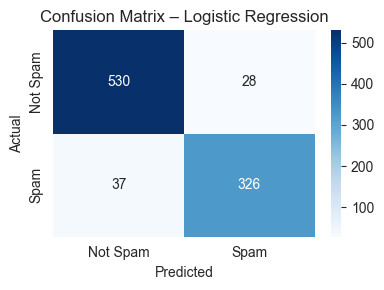

In [21]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()

### ROC Curve – Logistic Regression

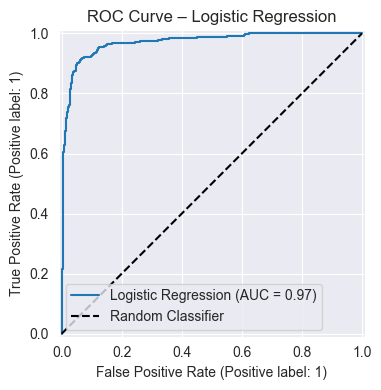

In [23]:
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, y_prob_log, ax=ax, name='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve – Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

In this lab, we built and evaluated two regression models on the Spambase dataset:

1. **Linear Regression** – When applied to a binary target, it produces continuous values that need to be thresholded for classification. The R² score indicates how well the model fits the data; however, it is not optimal for classification problems.

2. **Logistic Regression** – Naturally suited for binary classification. It achieved higher accuracy, precision, recall, and F1-Score compared to the thresholded linear model. The ROC-AUC score confirms its strong discriminative ability between spam and non-spam emails.

> **Key takeaway:** Logistic Regression significantly outperforms Linear Regression for binary classification tasks such as spam detection.